In [2]:
import rebound
import reboundx

sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.integrator='whfast'
sim.dt=10000.
sim.add(m=100.0)
star = sim.particles[0]


rebx = reboundx.Extras(sim)

sse = rebx.load_operator('stellar_evolution_sse')
rebx.add_operator(sse)
sim.step()

edw = rebx.load_operator('eddington_winds')
rebx.add_operator(edw)



print (star.m,star.r, star.params["sse_L"])

edw.params['edw_const']=1e-6

sim.integrate(sim.t+1000000000)

print (star.m,star.r, star.params["sse_L"])

#tdw.params['tdw_alpha_L']=1
#sim.integrate(sim.t+100000000000)

#print (star.m,star.r, star.params["sse_L"])

#print (star.m,star.r, star.params["sse_L"])
#print (star.params["edw_R"])

100.0 39.810717055349734 10000000.0
63.39572769846256 27.646998760982406 2028663.2863522433


100.0 0.0 1.0
99.999989375 39.81071367143875 9999996.281250494


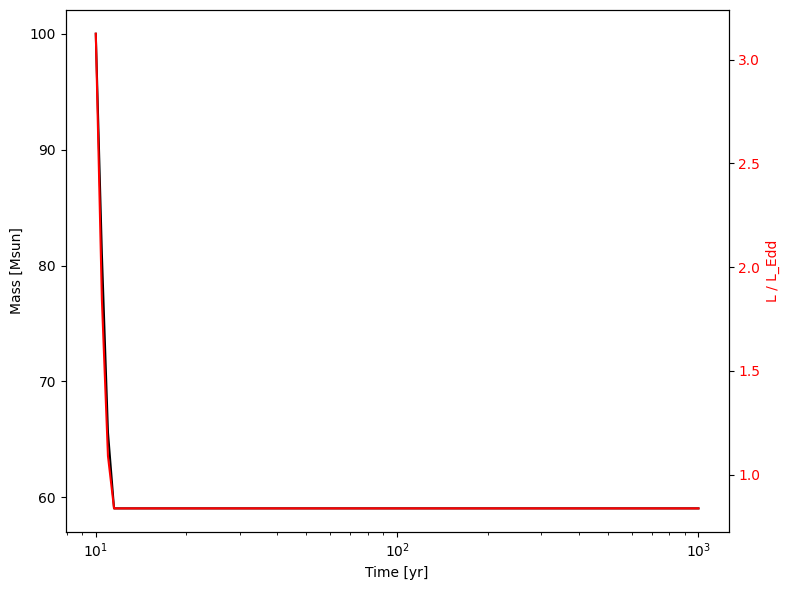

In [15]:
import matplotlib.pyplot as plt
import numpy as np

sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.integrator='whfast'
sim.dt=1e1
sim.add(m=100.0)
star = sim.particles[0]
rebx = reboundx.Extras(sim)
sse = rebx.load_operator('stellar_evolution_sse')
rebx.add_operator(sse)
edw = rebx.load_operator('eddington_winds')
rebx.add_operator(edw)
print (star.m,star.r, star.params["sse_L"])

sim.step()
print (star.m,star.r, star.params["sse_L"])


timearray = np.logspace(1,3,100)


masses = []
luminosities = []

for time in timearray:
    edw.params['edw_const']=star.params["sse_L"]/(2*40.*star.m/star.r)

    sim.integrate(time)
    masses.append(star.m)
    luminosities.append(star.params["sse_L"])

# --- Eddington luminosity ---
# (Simplified form: L_Edd ~ 3.2e4 (M/Msun) Lsun for H-rich composition)
def eddington_lum(mass):
    return 3.2e4 * mass  # in Lsun

Ledd = [eddington_lum(m) for m in masses]
Lratio = [L/Led for L, Led in zip(luminosities, Ledd)]

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(8,6))

ax1.set_xscale("log")
ax1.plot(timearray, masses, 'k-', label="Stellar Mass")
ax1.set_xlabel("Time [yr]")
ax1.set_ylabel("Mass [Msun]", color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Second y-axis for luminosity ratio
ax2 = ax1.twinx()
ax2.plot(timearray, Lratio, 'r-', label="L/L_Edd")
ax2.set_ylabel("L / L_Edd", color='r')
ax2.tick_params(axis='y', labelcolor='r')

fig.tight_layout()
plt.show()